<style>
.jp-Notebook h1, .jp-Notebook h2, .jp-Notebook h3 { letter-spacing: 0; }
.hero {
  padding: 14px 14px;
  border-radius: 14px;
  color: #ffffff;
  background: #323232;
  box-shadow: 0 8px 20px rgba(36, 76, 90, 0.14);
}
.hero h1 { margin: 0 0 8px 0; font-size: 2.4rem; }
.hero p { margin: 6px 0; font-size: 1.05rem; }
.hero p:last-child { margin-bottom: 0; }
.badge {
  display: inline-block;
  padding: 4px 10px;
  border-radius: 999px;
  background: rgba(255, 255, 255, 0.22);
  font-weight: 700;
  margin-bottom: 10px;
 }
</style>

<div class="hero">
  <div class="badge">🐍 Python Fundamentals</div>
  <h1>Everything In Python Is An Object</h1>
  <p>A practical mental model for object.</p>
  <p><strong>Lecture goal:</strong> Understand that Python variables refer to objects, and use this idea to explain common behavior such as list mutation, string immutability, and function assignment.</p>
</div>
<div style="height: 8px;"></div>

# Learning Roadmap

By the end of this lecture, you will understand following subjects:

| Section | What you will learn |
|---|---|
| 1. What is an object? | Value, type, identity, attributes, and methods |
| 2. Data type | Main data type in Python, mutable/immutable, and copy |
| 3. Methods and attributes | How objects expose data and behavior |
| 4. Variables | Why variables are names that refer to objects |

⚠️ <strong>Trainee prompt:</strong> Before starting, predict what will happen if two variables refer to the same list and one variable changes it. Keep your answer nearby.

---

# 1. What Is An Object?

An <strong>object</strong> is a piece of data that has:

| Property | Meaning | Example |
|---|---|---|
| Value | The actual data | `"Alice"` |
| Type | What kind of object it is | `str` |
| Identity | A unique identity for the object | Result of `id(name)` |
| Attributes | Data attached to the object | Object-specific values |
| Methods | Actions the object can perform | `name.upper()` |
| Reference count | How many references currently point to the object | `sys.getrefcount(name)`|

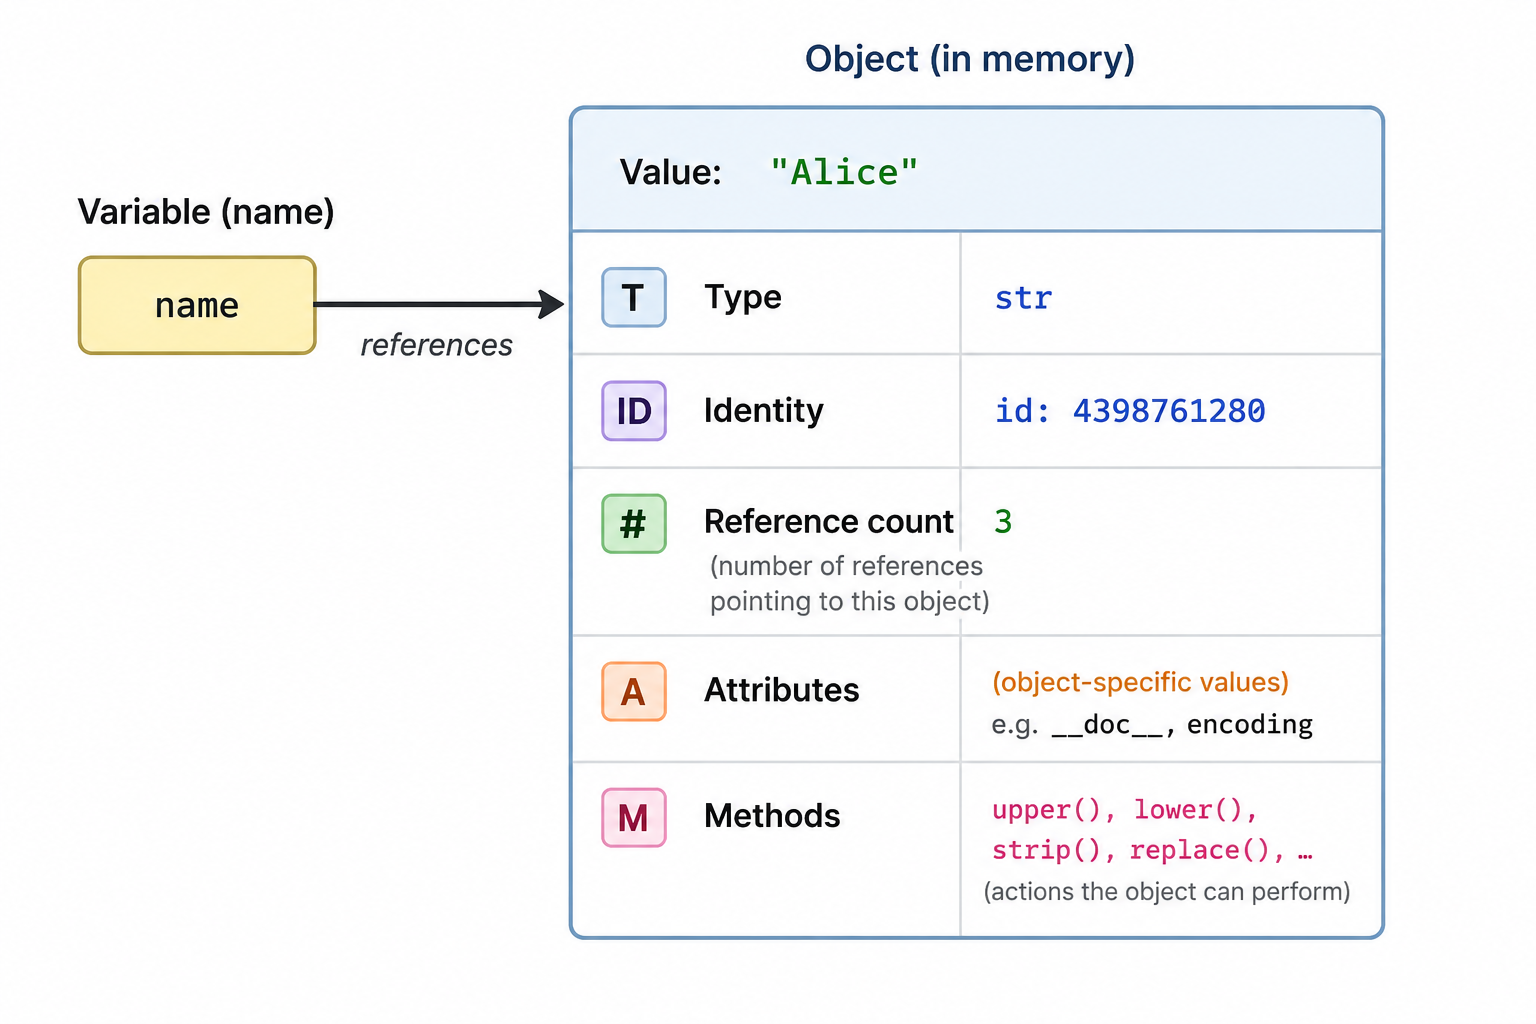

❓ <strong>Discussion:</strong> If a string has methods, is it only text, or is it something richer than plain text?

## 🗓️ Inspecting Objects

Python gives us built-in tools to inspect objects:

| Function | Use |
|---|---|
| `type(obj)` | Shows the type of an object |
| `id(obj)` | Shows the identity of an object |
| `dir(obj)` | Shows available attributes and methods |
| `help(obj)` | Shows documentation when available |

⚠️ <strong>Small correction:</strong> `id()` is often related to memory address in CPython, but you should treat it as an identity number, not as a portable memory-management tool.

In [ ]:
# Example: integer, string, list, dictionary, and NoneType
values = [100, "Python", [1, 2, 3], {"language": "Python"}, None]

for value in values:
    print("Value:", value)
    print("Type:", type(value))
    print("Attribute & Methods:", dir(value))
    print("Identity:", id(value))
    if isinstance(value, int):
        print("Method result:", value + 10)
    elif isinstance(value, str):
        print("Method result:", value.upper())
    elif isinstance(value, list):
        print("Method result:", value.index(2))
    elif isinstance(value, dict):
        print("Method result:", value.get("language"))
    elif isinstance(value, type(None)):
        print("Method result: None")
    print("-----")

# Press shift+enter to run the code

## 🗓️ Reference Count

In Python, objects live in memory. Variables (We will explain this later) do not directly “contain” the object.  
Instead, variables reference the object. Different variables can refer to the same object.

Reference count is important because Python uses it for memory management. When an object’s reference count becomes 0, Python can remove that object from memory.

### <b>Example</b>  

name = "Alice"  
student = name

Both variables point to the same object:

name    ───▶ "Alice"  
student ───▶ "Alice"

if you run following scripts

```python
import sys

name = ["Alice"]
print(sys.getrefcount(name))  # Reference count should be 2 (one for 'name' and one for the argument passed to getrefcount)

student = name
print(sys.getrefcount(name))  # Create another reference to the same list object, reference count should be 3
```

⚠️ <strong>Note</strong>: sys.getrefcount(name) returns a number that is usually 1 higher than expected, because passing name into getrefcount() temporarily adds another reference.

In [ ]:
# Example: Example
import sys

name = ["Alice"]
print(sys.getrefcount(name))  # Reference count should be 2 (one for 'name' and one for the argument passed to getrefcount)

student = name  # Create another reference to the same list object, reference count should be 3
print(sys.getrefcount(name))

del student  # Remove variable student, reference count should be 2
print(sys.getrefcount(name))

del name  # Remove variable name, reference count should be 0 so the object can be removed from memory
try:
    print(sys.getrefcount(name))  # You will get an error here because 'name' has been deleted and the object may have been garbage collected.
except NameError:
    print("Variable 'name' has been deleted.")

# Press shift+enter to run the code

---

# 2. Data Type

Here are main data types in Python.  

| Name | Type | Mutable? | Example |
|---|---|---:|---|
| Integer | `int` | No | `x = 10` |
| Float | `float` | No | `x = 3.14` |
| Complex number | `complex` | No | `x = 2 + 3j` |
| Boolean | `bool` | No | `x = True` |
| String | `str` | No | `x = "Python"` |
| List | `list` | Yes | `x = [1, 2, 3]` |
| Tuple | `tuple` | No | `x = (1, 2, 3)` |
| Range | `range` | No | `x = range(5)` |
| Dictionary | `dict` | Yes | `x = {"name": "Alice", "age": 20}` |
| Set | `set` | Yes | `x = {1, 2, 3}` |
| Frozen set | `frozenset` | No | `x = frozenset({1, 2, 3})` |
| Bytes | `bytes` | No | `x = b"hello"` |
| Byte array | `bytearray` | Yes | `x = bytearray(b"hello")` |
| None | `NoneType` | No | `x = None` |

⚠️ <strong>Notes:</strong> Functions and Classess are also objects. 

## 🗓️ Mutable And Immutable Objects

Python objects can be changed (Mutable) or cannot be changed (Immutable) based on data type.

| Group | Meaning |
|---|---|
| Mutable | Can change after creation |
| Immutable | Cannot change after creation |

What does it mean? Here is am exmaple with lists and strings how they behave differently.

In [ ]:
# Mutable object: the list changes in place
numbers = [1, 2, 3]
print("Before:", numbers, id(numbers))

numbers.append(4)
print("After:", numbers, id(numbers))

# Press shift+enter to run the code
# You will see same identity for the list but value has been changed.

In [ ]:
# Immutable object: the original string does not change
name = "alice"
print("Before:", name, id(name))

new_name = name.upper()
print("Original:", name, id(name))
print("New:", new_name, id(new_name))

# Press shift+enter to run the code
# You will see value was not changed but new value has different identity. It means new value is in another object and original object has not been chagned.

⚠️ <strong>Key message:</strong> Some methods mutate the object. Some methods return a new object. Read method behavior carefully.

In [ ]:
# Example: Mutable And Immutable Objects
a = [1, 2, 3]
b = a

print("value:", a, "id(a):", id(a))
print("value:", b, "id(b):", id(b))
print("Same object?", a is b)
print("Equal values?", a == b)

b.append(4)

print("a:", a)
print("b:", b)

# Press shift+enter to run the code

⚠️ <strong>Watch out:</strong> If you modified mutable object then all variables return updated values!!!  
For above case, althougth you want to update only variable "a" to be [1, 2, 3, 4], variable "b" still refer to the same object. That is why variables "a" and "b" return same outputs. How to update only variable "a"? Refer to following note.

## 🗓️ Copying A List

If you want two separate list objects, make a copy.

| Code | Result |
|---|---|
| `b = a` | `a` and `b` refer to the same list |
| `b = a.copy()` | `b` refers to a new shallow copy |
| `b = list(a)` | `b` refers to a new shallow copy |
| `b = a[:]` | `b` refers to a new shallow copy |

⚠️ <strong>Note:</strong> A shallow copy is enough for simple flat lists. Nested lists need extra care.

In [ ]:
# Example: Copying A List
a = [1, 2, 3]
b = a.copy()

b.append(4)

print("value:", a, "id(a):", id(a))
print("value:", b, "id(b):", id(b))
print("Same object?", a is b)
print("Equal values?", a == b)

# Press shift+enter to run the code

In [ ]:
# Example: Copying A List
a = [1, 2, 3]
b = list(a)

b.append(4)

print("value:", a, "id(a):", id(a))
print("value:", b, "id(b):", id(b))
print("Same object?", a is b)
print("Equal values?", a == b)

# Press shift+enter to run the code

In [ ]:
# Example: Copying A List
a = [1, 2, 3]
b = a[:]

b.append(4)

print("value:", a, "id(a):", id(a))
print("value:", b, "id(b):", id(b))
print("Same object?", a is b)
print("Equal values?", a == b)

# Press shift+enter to run the code

### 🗓️ Shallow Copy vs. Deep Copy

<b>1) Shallow copy</b>  
When an object is copied, the original object and the copied object refer to the same data in memory.  
If the data in the original object is changed, the copied object is also affected because it refers to the same data. As a result, the instance variables seen from the copied object also change.  
The shollow copy creates a new outer object, but keep references to the same inner objects.

<b>2) Deep copy</b>  
A deep copy copies not only the object itself, but also area of memory.
The data referenced by the two objects is separate, so changing an instance variable in one object does not affect the other object.  
The deep copy creates a new outer and inner objects.

⚠️ <strong>Note:</strong>  
<b>Outer object:</b> The main container object.  
<b>Inner object:</b> An object stored inside that container.  

\* Example: [1, 2, [3, 4]]  
Outer object: [1, 2, [3, 4]]  
Inner object: 1, 2, [3, 4]

In [ ]:
# Shallow copy
original = [1, 2, [3, 4]]
copied = original.copy()

print("Original list id:", id(original))
print("Copied list id:", id(copied))
print("Original list original[2] id:", id(original[2]))
print("Copied list copied[2] id:", id(copied[2]))
print("Outer objects are the same?", original is copied)
print("Inner objects are the same?", original[2] is copied[2])
print()

# Adding an element to the inner list of the copied list
print("Add 5 in the list list of copied list")
copied[2].append(5)
print("Original list:", original)
print("Copied list:", copied)
print("Outer objects are the same?", original is copied)
print("Inner objects are the same?", original[2] is copied[2])
print()

# Adding an element to the outer list of the copied list
print("Add 100 to the outer list")
copied.append(100)
print("Original list:", original)
print("Copied list:", copied)
print("Outer objects are the same?", original is copied)
print("Inner objects are the same?", original[2] is copied[2])

# Common ways to make a shallow copy
# copied = original.copy()
# copied = list(original)
# copied = original[:]

# Press shift+enter to run the code

In [ ]:
# Deep copy
import copy

original = [1, 2, [3, 4]]
deep = copy.deepcopy(original)

print("Original list id:", id(original))
print("Deep copy id:", id(deep))
print("Original list original[2] id:", id(original[2]))
print("Copied list deep[2] id:", id(deep[2]))
print("Original list is deep copy?", original is deep)
print("Inner objects are the same?", original[2] is deep[2])
print()

# Adding an element to the inner list of the copied list
print("Add 5 in the list list of copied list")
deep[2].append(5)
print("Original list:", original)
print("Copied list:", deep)
print("Outer objects are the same?", original is deep)
print("Inner objects are the same?", original[2] is deep[2])
print()

# Adding an element to the outer list of the copied list
print("Add 100 to the outer list")
deep.append(100)
print("Original list:", original)
print("Copied list:", deep)
print("Outer objects are the same?", original is deep)
print("Inner objects are the same?", original[2] is deep[2])

# Press shift+enter to run the code

---

# 3. Objects Have Methods And Attributes

A <strong>method</strong> is an action that belongs to an object.

A string object has methods such as:

- `.upper()`
- `.lower()`
- `.replace()`
- `.split()`
- `.strip()`

A list object has methods such as:

- `.append()`
- `.remove()`
- `.sort()`
- `.copy()`

❓ <strong>Discussion:</strong> Why does `name.upper()` use dot notation? What does the dot connect?

In [ ]:
# Example: 3. Objects Have Methods And Attributes
name = "alice"
message = " hello python "
scores = [80, 90, 100]

print(name.upper())
print(message.strip().title())

scores.append(95)
print(scores)

# Press shift+enter to run the code

In [ ]:
# We filter the result to show common string methods only.
text = "Python"

methods = [item for item in dir(text) if not item.startswith("_")]
print(methods[:20])

# Press shift+enter to run the code

---

In [ ]:
# Example: 3. Objects Have Methods And Attributes
class Student:
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def introduce(self):
        return f"My name is {self.name}. My score is {self.score}."

    def passed(self):
        return self.score >= 60

student = Student("Alice", 90)

print(student.name)
print(student.score)
print(student.introduce())
print(student.passed())

# Press shift+enter to run the code

You can use help() function to check descritpion of object

In [ ]:
# Example
help(list)

# Press shift+enter to run the code

---

# 4. Variables

Variables are names which refer to value (literal) of obejct.　　

1) Variables can be generated with upper/lower characters (a-z, A-Z), number (0-9) and underscore (_)
2) Variable names are case-sensitive.  
3) First character must be a latter or an underscore.  
4) Variable names cannot have space.
5) Variable names cannot be any of Pythons's reserved keywords:
 - https://peps.python.org/pep-0008/
 - https://medium.com/@pydatageek/python-reserved-keywords-a-comprehensive-explanation-426f763adbea


## Best practice
1) Snake Case: The preferred style for variables is snake_case (all lowercase with underscores between words), such as user_age or total_price.  
2) Descriptive Names: Use meaningful names that describe the data they hold. Instead of x = 5, use max_retry_limit = 5.  
3) Avoid Ambiguous Letters: Avoid using single-character names like lowercase 'l', uppercase 'O', or uppercase 'I', as they can be easily confused with '1' and '0'.  
4) Constants: If a value is intended to never change (a constant), name it in all capital letters, such as PI = 3.14 or MAX_SIZE = 100.

In [ ]:
# How to store literal values in variables
# To use "=" operator to store literal values in variables. The literal values can be of any data type such as integer, string, list, dictionary, etc.

a = 100
b = [1,2,3]
c = {"name": "Alice"}
d = "aa"
e = a + 12

print("a:", a)
print("b:", b)
print("c:", c)
print("d:", d)
print("e:", e)

# Press shift+enter to run the code

In [ ]:
# You can assign literal to multiple variables at once
x = y = z = 50

print("x:", x)
print("y:", y)
print("z:", z)

# Press shift+enter to run the code

In [ ]:
# If you try to add incompatible types, you will get a TypeError
f = a + d  # This will raise a TypeError because you cannot add an integer and a string together.

# Press shift+enter to run the code

---

# Knowledge Check

1. What basic properties does an object have?
2. What is the difference between `type()` and `id()`?
3. What is a Python variable in Python?
4. A list is referred by two variable `a` and `b`. Why does changing `b` also affect `a` after `b = a` when `a` is a list?
5. Why does `name.upper()` not change the original string?
6. Are functions and classes objects in Python?

---

# Key Terms

| Term | Meaning |
|---|---|
| Object | Data with value, type, identity, and behavior |
| Type | The kind of object |
| Identity | Unique identity of an object |
| Variable | A name that refers to an object |
| Attribute | Data that belongs to an object |
| Method | Function that belongs to an object |
| Mutable | Can be changed after creation |
| Immutable | Cannot be changed after creation |
| Class | Blueprint for creating objects |
| Instance | Object created from a class |

---

# Wrap-Up

Congratulations! You have finished the object session in Python.

Here are what we have learnt:

| Section | What you will learn |
|---|---|
| 1. What is an object? | Value, type, identity, attributes, and methods |
| 2. Data type | Main data type in Python, mutable/immutable, and copy |
| 3. Methods and attributes | How objects expose data and behavior |
| 4. Variables | Why variables are names that refer to objects |

Remember these core ideas:

- `type()` tells you what kind of object you have.
- `id()` helps you inspect object identity.
- Lists, dictionaries, and sets are mutable.
- Strings, numbers, tuples, and booleans are immutable.
- There are two copy methods; shallow and deep.
- Objects have attributes and methods.
- Variables are names which refer to value (literal) of obejct
- Functions and classes can be treated as objects too.

⚠️ <strong>Exit ticket:</strong> Explain this line in one sentence: `b = a`. Then explain what could go wrong if `a` is a list and you modify `b`.

---

© Training material was developed by dfolks.  
| Date | Log |
|---|---|
| May-2026 | 1st version |